# Email Spam Detection Using Machine Learning

## Objective

The goal of this project is to build a machine learning model that can classify emails as Spam or Not Spam.

Spam emails often contain promotional messages, suspicious links, and misleading information. Detecting them automatically helps improve email security and user experience.

In [1]:
from google.colab import files

uploaded = files.upload()

Saving completeSpamAssassin.csv.zip to completeSpamAssassin.csv.zip


In [2]:
!ls

completeSpamAssassin.csv.zip  sample_data


In [3]:
!unzip completeSpamAssassin.csv.zip

Archive:  completeSpamAssassin.csv.zip
  inflating: completeSpamAssassin.csv  


In [4]:
import pandas as pd

df = pd.read_csv("completeSpamAssassin.csv")

df.head()

,Unnamed: 0,Body,Label
0,0,\nSave up to 70% on Life Insurance.\nWhy Spend...,1
1,1,1) Fight The Risk of Cancer!\nhttp://www.adcli...,1
2,2,1) Fight The Risk of Cancer!\nhttp://www.adcli...,1
3,3,##############################################...,1
4,4,I thought you might like these:\n1) Slim Down ...,1


In [5]:
print(df.shape)

(6046, 3)


In [6]:
print(df['Label'].value_counts())

Label
0    4150
1    1896
Name: count, dtype: int64


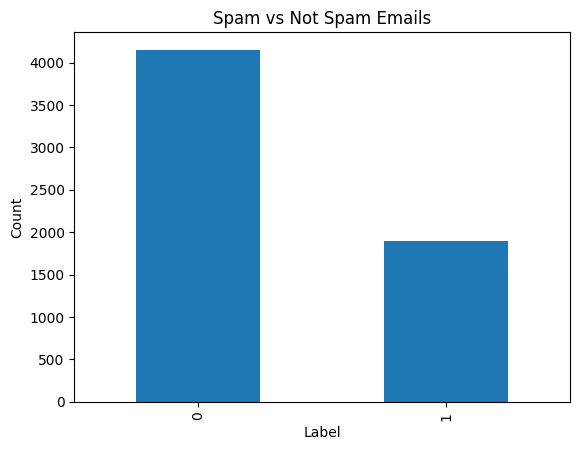

In [7]:
import matplotlib.pyplot as plt

df['Label'].value_counts().plot(kind='bar')

plt.title("Spam vs Not Spam Emails")
plt.xlabel("Label")
plt.ylabel("Count")

plt.show()

In [8]:
print(df['Body'][0])


Save up to 70% on Life Insurance.
Why Spend More Than You Have To?Life Quote Savings
Ensuring your 
      family's financial security is very important. Life Quote Savings makes 
      buying life insurance simple and affordable. We Provide FREE Access to The 
      Very Best Companies and The Lowest Rates.Life Quote Savings is FAST, EASY and 
            SAVES you money! Let us help you get started with the best values in 
            the country on new coverage. You can SAVE hundreds or even thousands 
            of dollars by requesting a FREE quote from Lifequote Savings. Our 
            service will take you less than 5 minutes to complete. Shop and 
            compare. SAVE up to 70% on all types of Life insurance! Click Here For Your 
            Free Quote!Protecting your family is the best investment you'll ever 
          make!
If you are in receipt of this email 
      in error and/or wish to be removed from our list, PLEASE CLICK HERE AND TYPE REMOVE. If you 
      resi

In [9]:
print(df[df['Label'] == 0]['Body'].iloc[0])

    Date:        Wed, 21 Aug 2002 10:54:46 -0500
    From:        Chris Garrigues 
    Message-ID:  <1029945287.4797.TMDA@deepeddy.vircio.com>
  | I can't reproduce this error.For me it is very repeatable... (like every time, without fail).This is the debug log of the pick happening ...18:19:03 Pick_It {exec pick +inbox -list -lbrace -lbrace -subject ftp -rbrace -rbrace} {4852-4852 -sequence mercury}
18:19:03 exec pick +inbox -list -lbrace -lbrace -subject ftp -rbrace -rbrace 4852-4852 -sequence mercury
18:19:04 Ftoc_PickMsgs {{1 hit}}
18:19:04 Marking 1 hits
18:19:04 tkerror: syntax error in expression "int ...Note, if I run the pick command by hand ...delta$ pick +inbox -list -lbrace -lbrace -subject ftp -rbrace -rbrace  4852-4852 -sequence mercury
1 hitThat's where the "1 hit" comes from (obviously).  The version of nmh I'm
using is ...delta$ pick -version
pick -- nmh-1.0.4 [compiled on fuchsia.cs.mu.OZ.AU at Sun Mar 17 14:55:56 ICT 2002]And the relevant part of my .mh_profile ...de

In [10]:
print(df.isnull().sum())

Unnamed: 0    0
Body          1
Label         0
dtype: int64


In [11]:
df['Body'] = df['Body'].fillna('')

In [12]:
print(df.isnull().sum())

Unnamed: 0    0
Body          0
Label         0
dtype: int64


In [13]:
df = df.drop('Unnamed: 0', axis=1)

df.head()

,Body,Label
0,\nSave up to 70% on Life Insurance.\nWhy Spend...,1
1,1) Fight The Risk of Cancer!\nhttp://www.adcli...,1
2,1) Fight The Risk of Cancer!\nhttp://www.adcli...,1
3,##############################################...,1
4,I thought you might like these:\n1) Slim Down ...,1


In [14]:
df['email_length'] = df['Body'].apply(len)

df[['email_length', 'Label']].head()

,email_length,Label
0,1111,1
1,753,1
2,610,1
3,2863,1
4,641,1


In [15]:
print(df.groupby('Label')['email_length'].mean())

Label
0    1699.373253
1    1886.265823
Name: email_length, dtype: float64


In [16]:
df['num_exclamations'] = df['Body'].apply(lambda x: x.count('!'))

df[['num_exclamations', 'Label']].head()

,num_exclamations,Label
0,4,1
1,2,1
2,2,1
3,16,1
4,1,1


In [17]:
print(df.groupby('Label')['num_exclamations'].mean())

Label
0    0.737108
1    4.628165
Name: num_exclamations, dtype: float64


In [18]:
df['num_caps'] = df['Body'].apply(lambda x: sum(1 for c in x if c.isupper()))

df[['num_caps', 'Label']].head()

,num_caps,Label
0,103,1
1,42,1
2,37,1
3,195,1
4,30,1


In [19]:
print(df.groupby('Label')['num_caps'].mean())

Label
0     74.428916
1    190.406118
Name: num_caps, dtype: float64


In [20]:
df['num_links'] = df['Body'].apply(
    lambda x: x.count('http')
)

df[['num_links', 'Label']].head()

,num_links,Label
0,0,1
1,7,1
2,6,1
3,6,1
4,5,1


In [21]:
print(df.groupby('Label')['num_links'].mean())

Label
0    2.746506
1    1.066983
Name: num_links, dtype: float64


In [23]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=3000)

X_text = tfidf.fit_transform(df['Body'])

In [24]:
print(X_text.shape)

(6046, 3000)


In [25]:
from sklearn.model_selection import train_test_split

y = df['Label']

X_train, X_test, y_train, y_test = train_test_split(
    X_text,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(4836, 3000)
(1210, 3000)


In [26]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [27]:
y_pred = model.predict(X_test)

In [28]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9570247933884297


In [33]:
sample_email = ["Congratulations! You have won $1000. Click here to claim your prize now!"]

sample_tfidf = tfidf.transform(sample_email)

prediction = model.predict(sample_tfidf)

print("Email:")
print(sample_email[0])
print()

if prediction[0] == 1:
    print("Prediction: SPAM")
else:
    print("Prediction: NOT SPAM")

Email:
Congratulations! You have won $1000. Click here to claim your prize now!

Prediction: SPAM


In [34]:
sample_email = ["Hi Karthik, the Network Theory class has been rescheduled to tomorrow at 10 AM. Please inform your classmates."]

sample_tfidf = tfidf.transform(sample_email)

prediction = model.predict(sample_tfidf)

print("Email:")
print(sample_email[0])
print()

if prediction[0] == 1:
    print("Prediction: SPAM")
else:
    print("Prediction: NOT SPAM")

Email:
Hi Karthik, the Network Theory class has been rescheduled to tomorrow at 10 AM. Please inform your classmates.

Prediction: NOT SPAM


In [35]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[775  33]
 [ 19 383]]


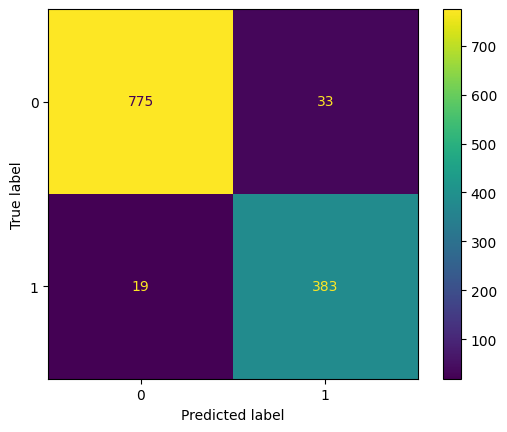

In [36]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

plt.show()

In [37]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.96      0.97       808
           1       0.92      0.95      0.94       402

    accuracy                           0.96      1210
   macro avg       0.95      0.96      0.95      1210
weighted avg       0.96      0.96      0.96      1210



# Conclusion

A Spam Email Detection System was developed using Machine Learning techniques. The dataset was analyzed and cleaned, followed by feature engineering and TF-IDF vectorization. A Logistic Regression model was trained and evaluated on unseen data.

The model achieved an accuracy of 95.7%, with strong precision and recall scores for both spam and non-spam email classification. Sample email testing further demonstrated the model's ability to correctly identify spam and legitimate messages.

This project highlights the practical application of Natural Language Processing (NLP) and Machine Learning for email filtering and classification.
